[source] total records: 40,078
[OK] category / country / ESG distributions match the reported figures.
     category: {'Regulation': 9614, 'Intl ESG': 7986, 'Gov/Corp ESG': 7951, 'Legislation': 7234, 'News': 4764, 'Legal case': 2529}
     country : {'Vietnam': 20079, 'Malaysia': 19999}
     esg     : {'E': 26342, 'S': 9104, 'G': 4632}

[fill-rate] clause reference within regulations, by country: {'Malaysia': 0.0, 'Vietnam': 0.2925}
            -> justifies excluding disclosure->clause mapping F1 as a primary metric
        field          desc  fill_rate
   content_ko       body ko     1.0000
   content_en       body en     1.0000
content_local    body local     1.0000
reg_reference    clause ref     0.0351
sanction_type sanction type     0.0547
  case_detail   case detail     0.0631

[cases] n=2,529 | result.type fill-rate=0.8671
        ESG dist: {'S': 1133, 'G': 771, 'E': 625}
        case_detail median length: 145 chars
        body median length (chars): {'ko': 3247, 'en': 6750, 'l

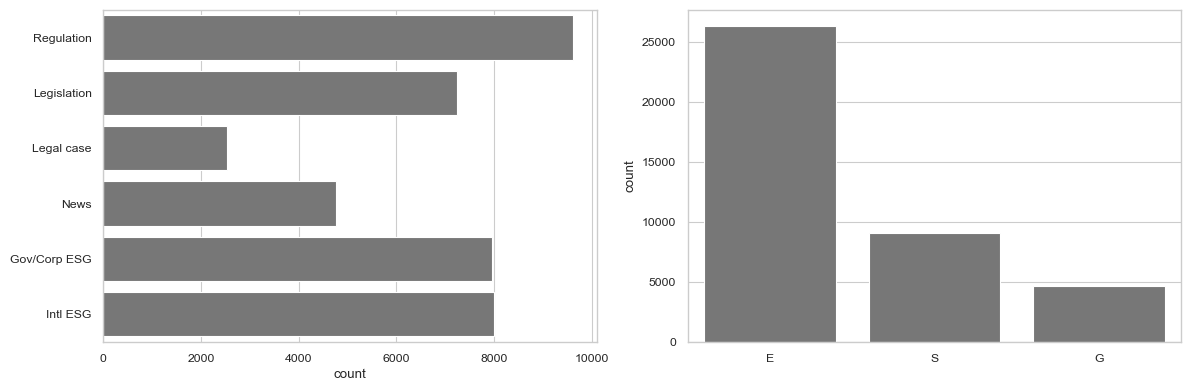

[save] table01, table01b

[done] notebook 01 complete.


In [2]:
# ============================================================================
# Notebook 01 · Data Parsing & Empirical Validation
# ----------------------------------------------------------------------------
# Parses the AI Hub "Vietnam/Malaysia ESG" source & label zips into DataFrames,
# validates that the distributions reproduce the reported figures, measures
# critical field fill-rates, and saves interim parquet + summary tables/figures.
#
# Reproducibility notes:
#   - All paths are computed from this file's location (no hardcoded absolutes).
#   - Raw zips are AUTO-DISCOVERED from data/raw (filenames are NOT hardcoded),
#     so separator/spacing differences (". " vs "__" vs " ") do not break it.
#   - Zip entries are iterated in sorted order; DataFrames are sorted by id.
#     => identical row order and aggregates on any OS.
#   - All outputs (figures, tables, console) are ENGLISH-ONLY: Korean category/
#     country names are normalized to English right after parsing.
#   - Content text (avg ~50k chars x 3 langs per doc) is NOT loaded into the
#     main table; only its length is kept. Full text is loaded on demand later.
# ============================================================================

import io
import os
import re
import json
import random
import zipfile
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# 0. Paths & configuration (this notebook lives in <PROJECT_ROOT>/notebooks/)
# ----------------------------------------------------------------------------
PROJECT_ROOT  = Path.cwd().parent
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR   = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
for _d in (INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 40)
# NOTE: all outputs (figures, tables, console) are English-only by design;
# Korean category/country names are normalized to English right after parsing.

# ----------------------------------------------------------------------------
# Auto-discover the raw zips instead of hardcoding filenames.
# Real AI Hub filenames use ". " as a separator (e.g. "TS_1. 베트남_01. 규제.zip"),
# which differs from the upload-time names. To stay robust to separator/spacing
# differences, we classify each zip by (country, 2-digit category code, is-label)
# parsed from its filename with tolerant regex.
# ----------------------------------------------------------------------------
# category code -> canonical Korean category name (as stored inside the JSON)
CATCODE_TO_NAME = {
    "01": "규제", "02": "입법 동향", "03": "판례",
    "04": "기사", "05": "정부 및 기업 ESG 자료", "06": "국제 ESG 자료",
}

def _classify_source_zip(fname):
    """(country, catcode) from a source zip filename, or None if not a source zip.

    Tolerant to separators: matches the country word and a 2-digit category code
    appearing after it (".", "_", or space around it).
    """
    base = Path(fname).name
    if not base.lower().endswith(".zip"):
        return None
    if base.startswith("02") and "라벨" in base:   # label zip, handled separately
        return None
    country = None
    if "베트남" in base:
        country = "베트남"
    elif "말레이시아" in base:
        country = "말레이시아"
    if country is None:
        return None
    m = re.search(r"_(\d{2})[._ ]", base)          # e.g. "_01. " / "_01_" / "_01 "
    if not m:
        return None
    return country, m.group(1)

def _find_source_zips(raw_dir):
    """Return [(path, country, catname), ...] sorted deterministically."""
    found = []
    for p in sorted(raw_dir.glob("*.zip")):
        info = _classify_source_zip(p.name)
        if info is None:
            continue
        country, catcode = info
        catname = CATCODE_TO_NAME.get(catcode, catcode)
        found.append((p, country, catname))
    found.sort(key=lambda t: (t[1], t[0].name))    # stable order across machines
    return found

def _find_label_zip(raw_dir):
    """Locate the label zip (starts with '02' and contains '라벨')."""
    for p in sorted(raw_dir.glob("*.zip")):
        if p.name.startswith("02") and "라벨" in p.name:
            return p
    return None

# ---------------------------------------------------------------------------
# Korean -> English normalization (applied to the parsed DataFrame so that all
# downstream tables / figures / console output are English-only).
# ---------------------------------------------------------------------------
CATEGORY_KO2EN = {
    "규제": "Regulation",
    "입법 동향": "Legislation",
    "판례": "Legal case",
    "기사": "News",
    "정부 및 기업 ESG 자료": "Gov/Corp ESG",
    "국제 ESG 자료": "Intl ESG",
}
COUNTRY_KO2EN = {"베트남": "Vietnam", "말레이시아": "Malaysia"}

# Canonical English category order (used for stable table/figure ordering)
CATEGORY_ORDER_EN = ["Regulation", "Legislation", "Legal case",
                     "News", "Gov/Corp ESG", "Intl ESG"]

# Expected values (parsing must reproduce these locally; else data is missing)
EXPECTED_SOURCE_TOTAL = 40078
EXPECTED_CATEGORY_COUNTS = {
    "Regulation": 9614, "Intl ESG": 7986, "Gov/Corp ESG": 7951,
    "Legislation": 7234, "News": 4764, "Legal case": 2529,
}
EXPECTED_COUNTRY_COUNTS = {"Vietnam": 20079, "Malaysia": 19999}
EXPECTED_ESG_COUNTS = {"E": 26342, "S": 9104, "G": 4632}

# ----------------------------------------------------------------------------
# Figure styling: seaborn, grayscale, no titles, dpi=600, save as PNG + PDF.
# ----------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette("Greys_r")
FIG_DPI = 600
GREY_DARK, GREY_MID, GREY_LIGHT = "#333333", "#777777", "#BBBBBB"

def save_fig(fig, stem):
    """Save a figure to results/figures as both PNG and PDF at dpi=600.
    stem is a bare filename (no path is printed)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
    print(f"[save] figure {stem} (png, pdf)")

# ----------------------------------------------------------------------------
# 1. Parsing helpers
# ----------------------------------------------------------------------------
def _iter_json_in_zip(zf):
    """Yield parsed JSON objects from a zip, in sorted filename order."""
    for name in sorted(zf.namelist()):
        if not name.endswith(".json"):
            continue
        with zf.open(name) as fh:
            try:
                yield json.load(fh)
            except json.JSONDecodeError:
                continue

def _flatten_meta_record(d):
    """Flatten one source JSON to a lightweight row (metadata only).

    The trilingual content is huge (~50k chars x 3), so we keep only its
    length here and load the raw text on demand in later notebooks.
    """
    data    = d.get("data", {}) or {}
    m       = d.get("metadata", {}) or {}
    reg     = m.get("regulation", {}) or {}
    ci      = m.get("case_info", {}) or {}
    result  = ci.get("result", {}) or {}
    content = data.get("content", {}) or {}
    return {
        "id":            m.get("id", ""),          # metadata.id (join key for nodes)
        "doc_id":        data.get("id", ""),       # data.id  (join key for QA source_id)
        "file_name":     m.get("file_name", ""),
        "category":      m.get("category", ""),
        "country":       m.get("country", ""),
        "region":        m.get("region", ""),
        "title":         m.get("title", ""),
        "alias":         m.get("alias", ""),
        "esg":           m.get("esg", ""),
        "document_type": m.get("document_type", ""),
        "publisher":     m.get("publisher", ""),
        "entity":        m.get("entity", ""),
        "published_at":  m.get("published_at", ""),
        "source":        m.get("source", ""),
        "copyrighter":   m.get("copyrighter", ""),
        # content: keep length only (fill-rate can still be judged by len > 0)
        "len_ko":    len(content.get("ko", "") or ""),
        "len_en":    len(content.get("en", "") or ""),
        "len_local": len(content.get("local", "") or ""),
        # regulation clause fields
        "reg_name":       reg.get("regulation_name", "") or "",
        "reg_reference":  reg.get("regulation_reference", "") or "",
        "effective_date": reg.get("effective_date", "") or "",
        # legal-case case_info fields
        "case_detail":        ci.get("detail", "") or "",
        "pollutant_category": ci.get("pollutant_category", "") or "",
        "sanction_type":      result.get("type", "") or "",
        "sanction_level":     result.get("level", "") or "",
        "violation_date":     result.get("violation_date", "") or "",
        "sanction_date":      result.get("sanction_date", "") or "",
        "previous_violations": json.dumps(ci.get("previous_violations", []), ensure_ascii=False),
    }

def load_source(raw_dir=RAW_DIR):
    """Parse all source zips into one lightweight metadata DataFrame.

    Zips are auto-discovered from raw_dir (filenames are not hardcoded).
    """
    found = _find_source_zips(raw_dir)
    if not found:
        raise FileNotFoundError(
            "No source zips found under data/raw/.\n"
            "-> Place the AI Hub raw zips (TS_1.*/TS_2.*) under data/raw/."
        )
    if len(found) != 12:
        print(f"[warn] expected 12 source zips, found {len(found)}")
    rows = []
    for zpath, _country, _catname in found:
        with zipfile.ZipFile(zpath) as zf:
            for d in _iter_json_in_zip(zf):
                rows.append(_flatten_meta_record(d))
    df = pd.DataFrame(rows).sort_values("id", kind="mergesort").reset_index(drop=True)
    return df

def _classify_label_zip(inner_name):
    """Classify an inner label zip as 'qa' or 'benchmark' by its filename."""
    base = Path(inner_name).name
    if "QA" in base:
        return "qa"
    if "벤치마크" in base or "benchmark" in base.lower():
        return "benchmark"
    return "unknown"

def load_labels(raw_dir=RAW_DIR):
    """Parse the nested label zip into (qa_df, benchmark_df).

    Structure: outer zip -> inner zips (country x {QA, benchmark} x category).
    QA turns use role/content; benchmark turns use q_content/a_option/a_index.
    """
    zpath = _find_label_zip(raw_dir)
    if zpath is None:
        raise FileNotFoundError(
            "Label zip (02*라벨*.zip) not found under data/raw/."
        )
    qa_rows, bm_rows = [], []
    with zipfile.ZipFile(zpath) as outer:
        for name in sorted(outer.namelist()):
            if not name.endswith(".zip"):
                continue
            kind = _classify_label_zip(name)
            inner_bytes = outer.read(name)
            with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner_zf:
                for d in _iter_json_in_zip(inner_zf):
                    qa = d.get("qa", {}) or {}
                    base = {
                        "id":        d.get("id", ""),
                        "category":  qa.get("category", ""),
                        "country":   qa.get("country", ""),
                        "esg":       qa.get("ESG", ""),
                        "source_id": json.dumps(qa.get("source_id", []), ensure_ascii=False),
                    }
                    if kind == "qa":
                        turns = qa.get("qa_turns", [])
                        base["n_turns"]  = len(turns)
                        base["qa_turns"] = json.dumps(turns, ensure_ascii=False)
                        qa_rows.append(base)
                    elif kind == "benchmark":
                        turns = qa.get("qa_turns", [])
                        t0 = turns[0] if turns else {}
                        base["question"]     = t0.get("q_content", "")
                        base["options"]      = json.dumps(t0.get("a_option", []), ensure_ascii=False)
                        base["answer_index"] = t0.get("a_index", -1)
                        base["explanation"]  = t0.get("a_explanation", "")
                        bm_rows.append(base)
    qa_df = pd.DataFrame(qa_rows).sort_values("id", kind="mergesort").reset_index(drop=True)
    bm_df = pd.DataFrame(bm_rows).sort_values("id", kind="mergesort").reset_index(drop=True)
    return qa_df, bm_df

# ----------------------------------------------------------------------------
# 2. Parse source data + normalize Korean -> English
# ----------------------------------------------------------------------------
df = load_source()

# Normalize Korean category/country values to English (outputs are English-only).
# 'category'/'country' come from inside the JSON, so map them here; keep the raw
# Korean originals in *_ko columns for traceability/debugging.
df["category_ko"] = df["category"]
df["country_ko"]  = df["country"]
df["category"] = df["category"].map(CATEGORY_KO2EN).fillna(df["category"])
df["country"]  = df["country"].map(COUNTRY_KO2EN).fillna(df["country"])
print(f"[source] total records: {len(df):,}")

# ----------------------------------------------------------------------------
# 3. Empirical validation — assert distributions match reported figures
#    (If a value differs locally, parsing stops immediately: data mismatch.)
# ----------------------------------------------------------------------------
cat_counts     = df["category"].value_counts().to_dict()
country_counts = df["country"].value_counts().to_dict()
esg_counts     = df["esg"].value_counts().to_dict()

assert len(df) == EXPECTED_SOURCE_TOTAL,       (len(df), EXPECTED_SOURCE_TOTAL)
assert cat_counts     == EXPECTED_CATEGORY_COUNTS, cat_counts
assert country_counts == EXPECTED_COUNTRY_COUNTS, country_counts
assert esg_counts     == EXPECTED_ESG_COUNTS,      esg_counts
print("[OK] category / country / ESG distributions match the reported figures.")
print("     category:", cat_counts)
print("     country :", country_counts)
print("     esg     :", esg_counts)

# ----------------------------------------------------------------------------
# 4. Critical field fill-rates (design rationale: what is / isn't usable)
# ----------------------------------------------------------------------------
def fill_rate_str(series):
    s = series.fillna("").astype(str).str.strip()
    return (s != "").mean()

def fill_rate_len(series):
    return (series.fillna(0) > 0).mean()

fill_df = pd.DataFrame([
    {"field": "content_ko",    "desc": "body ko",       "fill_rate": round(fill_rate_len(df["len_ko"]), 4)},
    {"field": "content_en",    "desc": "body en",       "fill_rate": round(fill_rate_len(df["len_en"]), 4)},
    {"field": "content_local", "desc": "body local",    "fill_rate": round(fill_rate_len(df["len_local"]), 4)},
    {"field": "reg_reference", "desc": "clause ref",    "fill_rate": round(fill_rate_str(df["reg_reference"]), 4)},
    {"field": "sanction_type", "desc": "sanction type", "fill_rate": round(fill_rate_str(df["sanction_type"]), 4)},
    {"field": "case_detail",   "desc": "case detail",   "fill_rate": round(fill_rate_str(df["case_detail"]), 4)},
])

# Clause-reference fill-rate by country: the reason mapping-F1 is dropped
reg = df[df["category"] == "Regulation"]
reg_ref_by_country = (
    reg.assign(filled=reg["reg_reference"].fillna("").str.strip() != "")
       .groupby("country")["filled"].mean().round(4).to_dict()
)
print("\n[fill-rate] clause reference within regulations, by country:", reg_ref_by_country)
print("            -> justifies excluding disclosure->clause mapping F1 as a primary metric")
print(fill_df.to_string(index=False))

# Legal cases: case_info.result is the only basis for compliance labels (nb 03)
case = df[df["category"] == "Legal case"].copy()
print(f"\n[cases] n={len(case):,} | result.type fill-rate={fill_rate_str(case['sanction_type']):.4f}")
print(f"        ESG dist: {case['esg'].value_counts().to_dict()}")
print(f"        case_detail median length: {case['case_detail'].str.len().median():.0f} chars")
print("        body median length (chars):",
      {"ko": int(df['len_ko'].median()), "en": int(df['len_en'].median()), "local": int(df['len_local'].median())})

# ----------------------------------------------------------------------------
# 5. Parse label data (QA + benchmark) + normalize to English
# ----------------------------------------------------------------------------
qa_df, bm_df = load_labels()
for _d in (qa_df, bm_df):
    _d["category"] = _d["category"].map(CATEGORY_KO2EN).fillna(_d["category"])
    _d["country"]  = _d["country"].map(COUNTRY_KO2EN).fillna(_d["country"])
print(f"\n[labels] QA: {len(qa_df):,} | benchmark: {len(bm_df):,}")
print("[labels] QA by country/category:")
print(qa_df.groupby(["country", "category"]).size())
print("[labels] benchmark answer-index distribution:")
print(bm_df["answer_index"].value_counts().sort_index())

# ----------------------------------------------------------------------------
# 6. Save interim parquet + summary tables + figure
# ----------------------------------------------------------------------------
df.to_parquet(INTERIM_DIR / "source.parquet", index=False)
qa_df.to_parquet(INTERIM_DIR / "qa.parquet", index=False)
bm_df.to_parquet(INTERIM_DIR / "benchmark.parquet", index=False)
print("[save] interim parquet (source / qa / benchmark)")

# Table 01: category x country crosstab
pivot = pd.crosstab(df["category"], df["country"], margins=True, margins_name="Total")
pivot = pivot.reindex(CATEGORY_ORDER_EN + ["Total"])
pivot.to_csv(TABLES_DIR / "table01_category_country.csv", encoding="utf-8-sig")

# Table 01b: fill-rate
fill_df.to_csv(TABLES_DIR / "table01b_fill_rate.csv", index=False, encoding="utf-8-sig")

# Figure 01: category & ESG distributions (seaborn, grayscale, no titles)
cat_order = CATEGORY_ORDER_EN  # counts already keyed by English names

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=[cat_counts[c] for c in cat_order], y=cat_order,
            color=GREY_MID, ax=axes[0])
axes[0].set_xlabel("count")
axes[0].set_ylabel("")
esg_order = ["E", "S", "G"]
sns.barplot(x=esg_order, y=[esg_counts[e] for e in esg_order],
            color=GREY_MID, ax=axes[1])
axes[1].set_xlabel("")
axes[1].set_ylabel("count")
fig.tight_layout()
save_fig(fig, "fig01_distribution")
plt.show()
print("[save] table01, table01b")

print("\n[done] notebook 01 complete.")